# Compare CW waveform model in `float32` with `float64`

RUN THIS NOTEBOOK IN FLOAT32!!!

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr

import pickle

import matplotlib.pyplot as plt
import corner

from enterprise_extensions.deterministic import cw_delay

import prometheus.deterministic as det
from prometheus.deterministic_models import DeterministicModel
from prometheus import utilities as utils

%load_ext autoreload
%autoreload 2

libstempo not installed. PINT or libstempo are required to use par and tim files.


In [2]:
# load the NG15 data to get example pulsar positions, distances, etc.
with open('../../data/NG15/data.pkl', 'rb') as fp:
    NG15_data = pickle.load(fp)

In [3]:
# CW parameter bounds
cw_source_mins = jnp.array([7., -8.7, -1., 0, -18., -1., 0., 0.])
cw_source_maxs = jnp.array([9., -8.2, 1., jnp.pi, -12., 1., 2. * jnp.pi, 2. * jnp.pi])
cw_parameter_bounds = jnp.vstack((cw_source_mins, cw_source_maxs)).T

cw_model_float32 = DeterministicModel(name='cw_params',
                                      data=NG15_data,
                                      get_delays_func=det.cw_delay_full_prior_float32,
                                      parameter_bounds=cw_parameter_bounds)

vectorized_cw_delay_float32 = jax.vmap(cw_model_float32.get_delays_func, in_axes=(None, None, 0, 0, 0))

In [4]:
# load float64 results
with open('float64_results.pkl', 'rb') as fp:
    float64_results = pickle.load(fp)

In [5]:
float32_waveforms = vectorized_cw_delay_float32(float64_results['scaled_shifted_toas'],
                                                float64_results['psrpos'],
                                                float64_results['cw_params'],
                                                float64_results['psr_phases_prior'],
                                                float64_results['psr_dists_prior'])
print(float32_waveforms.shape)

(100, 67, 122)


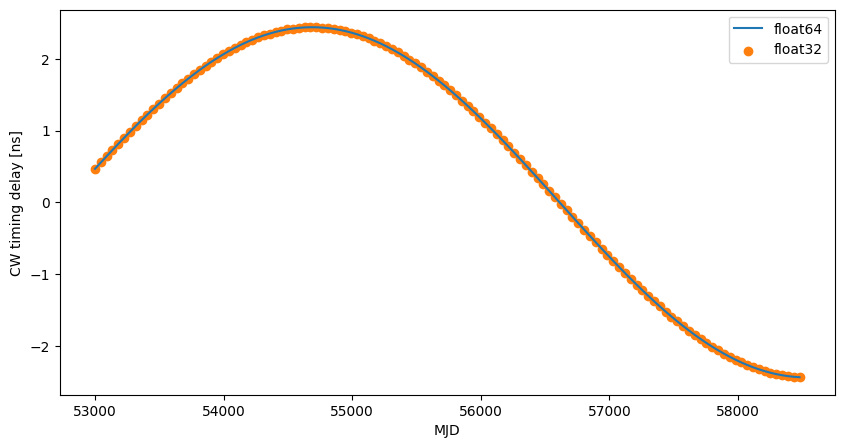

In [6]:
samp_ndx = 77
psr_ndx = 51

plt.figure(figsize=(10, 5))
plt.plot(float64_results['toas'][psr_ndx] / utils.day, float64_results['float64_CW_waveforms'][samp_ndx, psr_ndx], color='C0', label='float64')
plt.scatter(float64_results['toas'][psr_ndx] / utils.day, float32_waveforms[samp_ndx, psr_ndx], color='C1', label='float32')
plt.xlabel('MJD')
plt.ylabel('CW timing delay [ns]')
plt.legend()
plt.show()

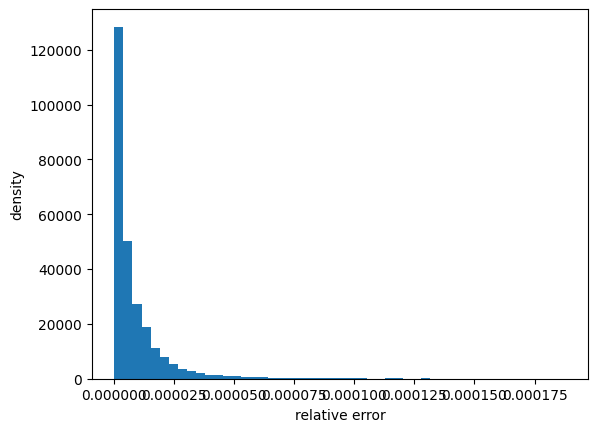

In [7]:
rel_err = np.sum(np.abs(float64_results['float64_CW_waveforms'] - float32_waveforms), axis=1) / np.sum(np.abs(float64_results['float64_CW_waveforms']), axis=1)
plt.hist(rel_err.flatten(), density=True, bins=50)
plt.xlabel('relative error')
plt.ylabel('density')
plt.show()

In [8]:
F_D = np.zeros((float64_results['toas'][0].shape[0], 2 * NG15_data.nfreqs_det))
for j in range(NG15_data.nfreqs_det):
    F_D[:, 2 * j] = np.sin(2. * np.pi * NG15_data.freqs_forFFT[0, j + 1] * float64_results['toas'][0])
    F_D[:, 2 * j + 1] = np.cos(2. * np.pi * NG15_data.freqs_forFFT[0, j + 1] * float64_results['toas'][0])

In [9]:
vectorized_get_coeffs = jax.vmap(cw_model_float32.get_coeffs_func, in_axes=(0, 0, 0))
float32_a_cw = vectorized_get_coeffs(float64_results['cw_params'],
                                     float64_results['psr_phases_prior'],
                                     float64_results['psr_dists_prior'])
float32_waveforms_via_FFT = jax.vmap(lambda a_cw_per_psr: jax.vmap(lambda a_cw: F_D @ a_cw)(a_cw_per_psr))(float32_a_cw)

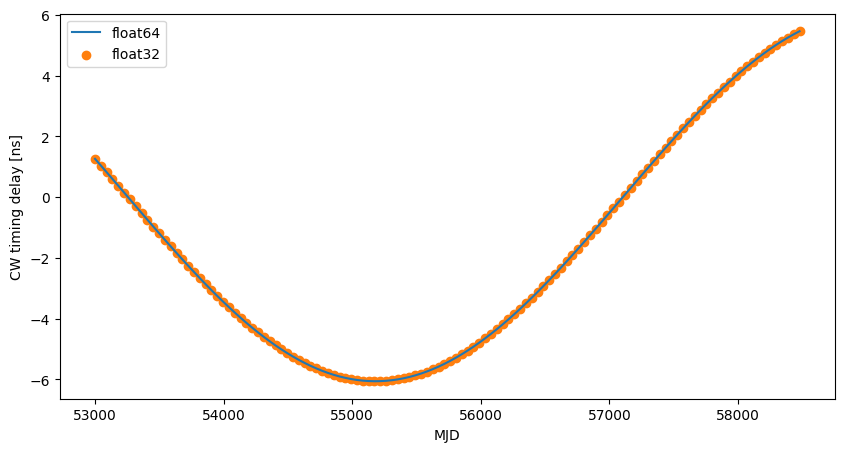

In [10]:
samp_ndx = 77
psr_ndx = 58

plt.figure(figsize=(10, 5))
plt.plot(float64_results['toas'][psr_ndx] / utils.day, float64_results['float64_CW_waveforms'][samp_ndx, psr_ndx], color='C0', label='float64')
plt.scatter(float64_results['toas'][psr_ndx] / utils.day, float32_waveforms_via_FFT[samp_ndx, psr_ndx], color='C1', label='float32')
plt.xlabel('MJD')
plt.ylabel('CW timing delay [ns]')
plt.legend()
plt.show()

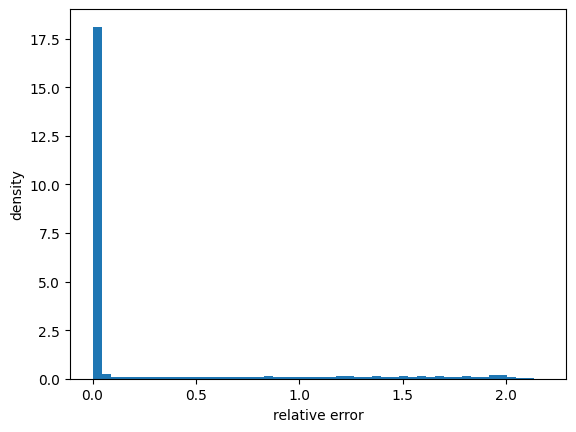

In [11]:
rel_err = np.sum(np.abs(float64_results['float64_CW_waveforms'] - float32_waveforms_via_FFT), axis=1) / np.sum(np.abs(float64_results['float64_CW_waveforms']), axis=1)
plt.hist(rel_err.flatten(), density=True, bins=50)
plt.xlabel('relative error')
plt.ylabel('density')
plt.show()